Loaded delta-0.1-45.txt: angle=45.0°, Fx=2.666e+01, Fy=2.666e+01, components=x, n_points=30
maximum displacement (x): 5.946
sigma_noise added (x): 0.1189 (2.0% of maximum displacement)
realized experimental noise (x): 0.1256
sigma_noise prior: Exp(beta=1.676)
Saved figure: c:\Users\paraj\Documents\particle_inference_test\examples\plots\data_vs_noise.pdf


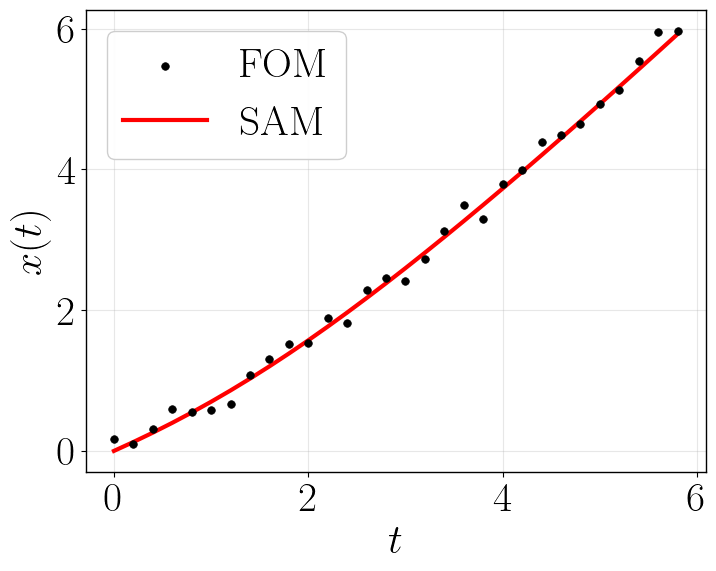

Saved figure: c:\Users\paraj\Documents\particle_inference_test\examples\plots\model_error.pdf


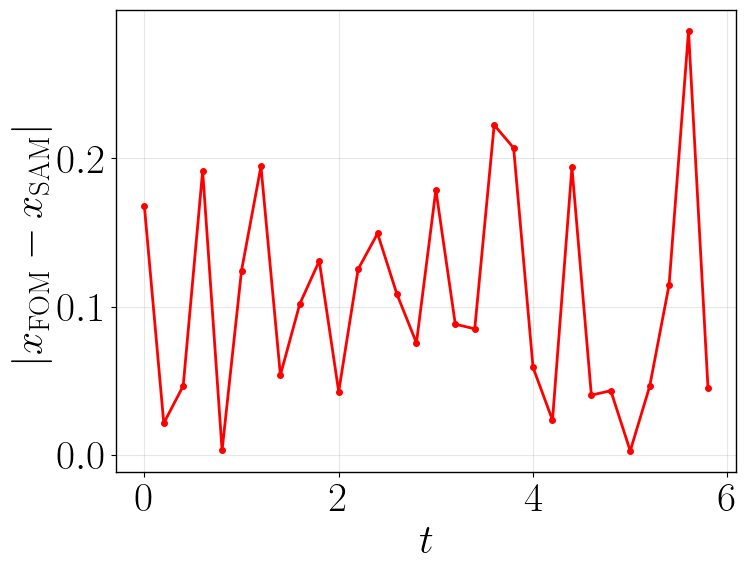

x model error: max |error| = 0.28573, mean |error| = 0.105752
Saved figure: c:\Users\paraj\Documents\particle_inference_test\examples\plots\prior.pdf


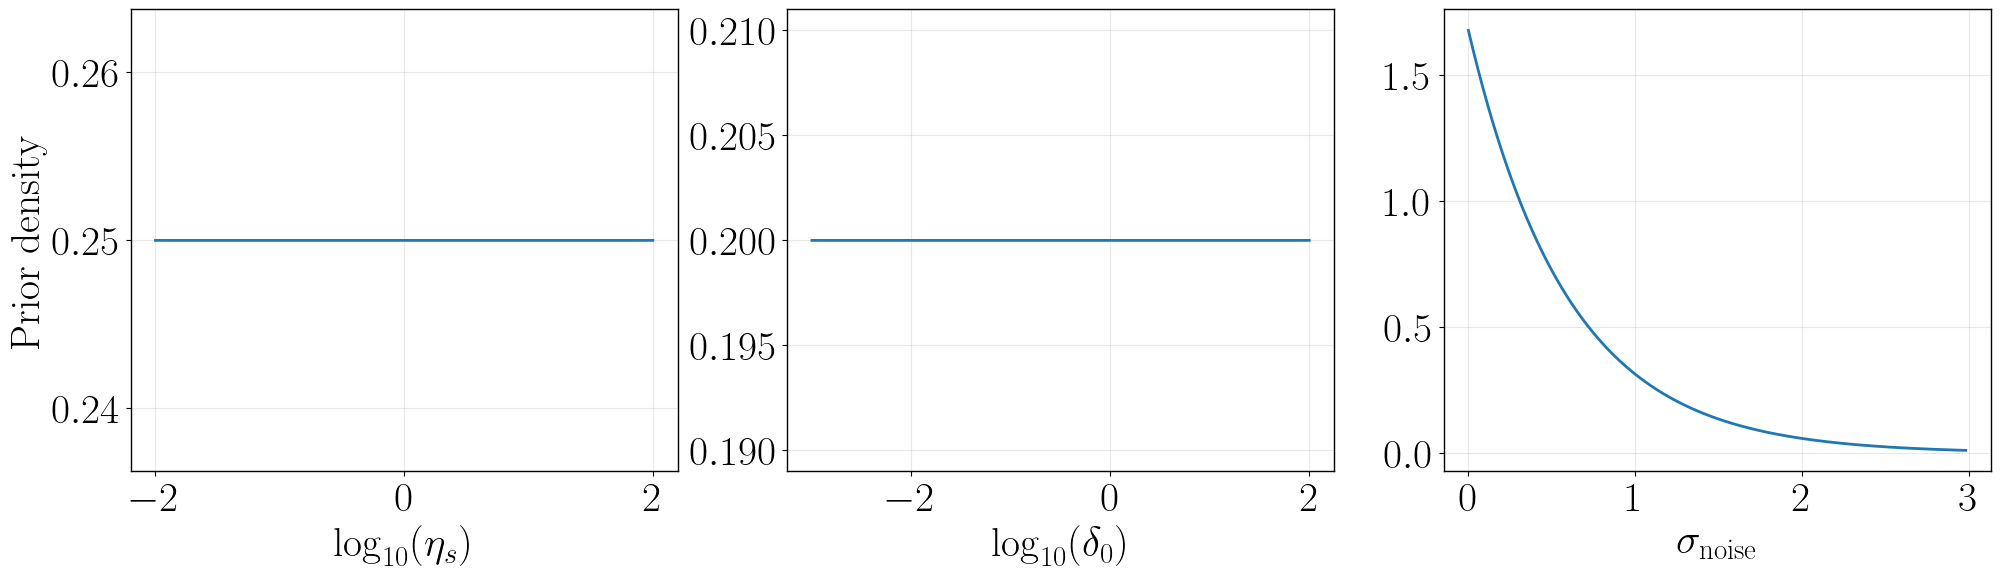


Preparing MCMC: ndim=3, walkers=6, steps=10000, init=kmeans, warmup=True

Initial walkers (physical):
  00: [ 0.12052486 14.07369729  0.51712156]
  01: [9.88738521e+00 6.52956375e-03 6.80940222e-01]
  02: [0.06869367 0.2146696  0.8546905 ]
  03: [12.27838545 12.69644085  0.72294936]
  04: [0.10516009 0.00483564 0.62646199]
  05: [6.71745297 0.21370426 0.4671217 ]

Warm-up: 1000 steps x 6 walkers


Warm-up:   0%|          | 0/1000 [00:00<?, ?it/s]


Walkers after warm-up (physical):
  00: [0.9793874  0.09001474 0.11812938]
  01: [0.9638337  0.07624438 0.13223924]
  02: [0.97722883 0.08832499 0.11514942]
  03: [0.99378407 0.09246972 0.12114595]
  04: [0.96949097 0.08528938 0.11501322]
  05: [0.97524129 0.08179476 0.1254528 ]


MCMC:   0%|          | 0/10000 [00:00<?, ?it/s]


MCMC Diagnostics Summary
Chains: 6  |  Samples/chain after burn-in: 7000  |  Total: 42000
----------------------------------------------------------------
Parameter                Mean            Std       Rhat
----------------------------------------------------------------
eta_s              9.7505e-01     2.9183e-02     1.0006
delta              8.8311e-02     2.6740e-02     1.0004
sigma_noise        1.3119e-01     1.8476e-02     1.0018
----------------------------------------------------------------
Mean Rhat                                        1.0009
Std Rhat                                         0.0006

All parameters show good convergence (Rhat <= 1.1)


Posterior-predictive adequacy (x, replicated data):
  Nominal central coverage of band:  95.0%
  ----------------------------------------------------------------
  series               cover     RMS z    max|z|    mean z
  dataset[0] x        100.0%      0.89      1.75      0.08
Saved figure: c:\Users\paraj\Documents\parti

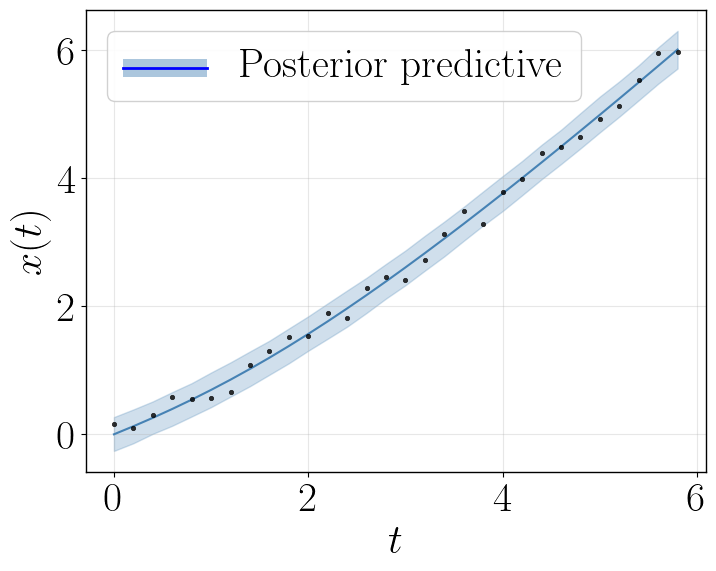

Saved figure: c:\Users\paraj\Documents\particle_inference_test\examples\plots\corner.pdf


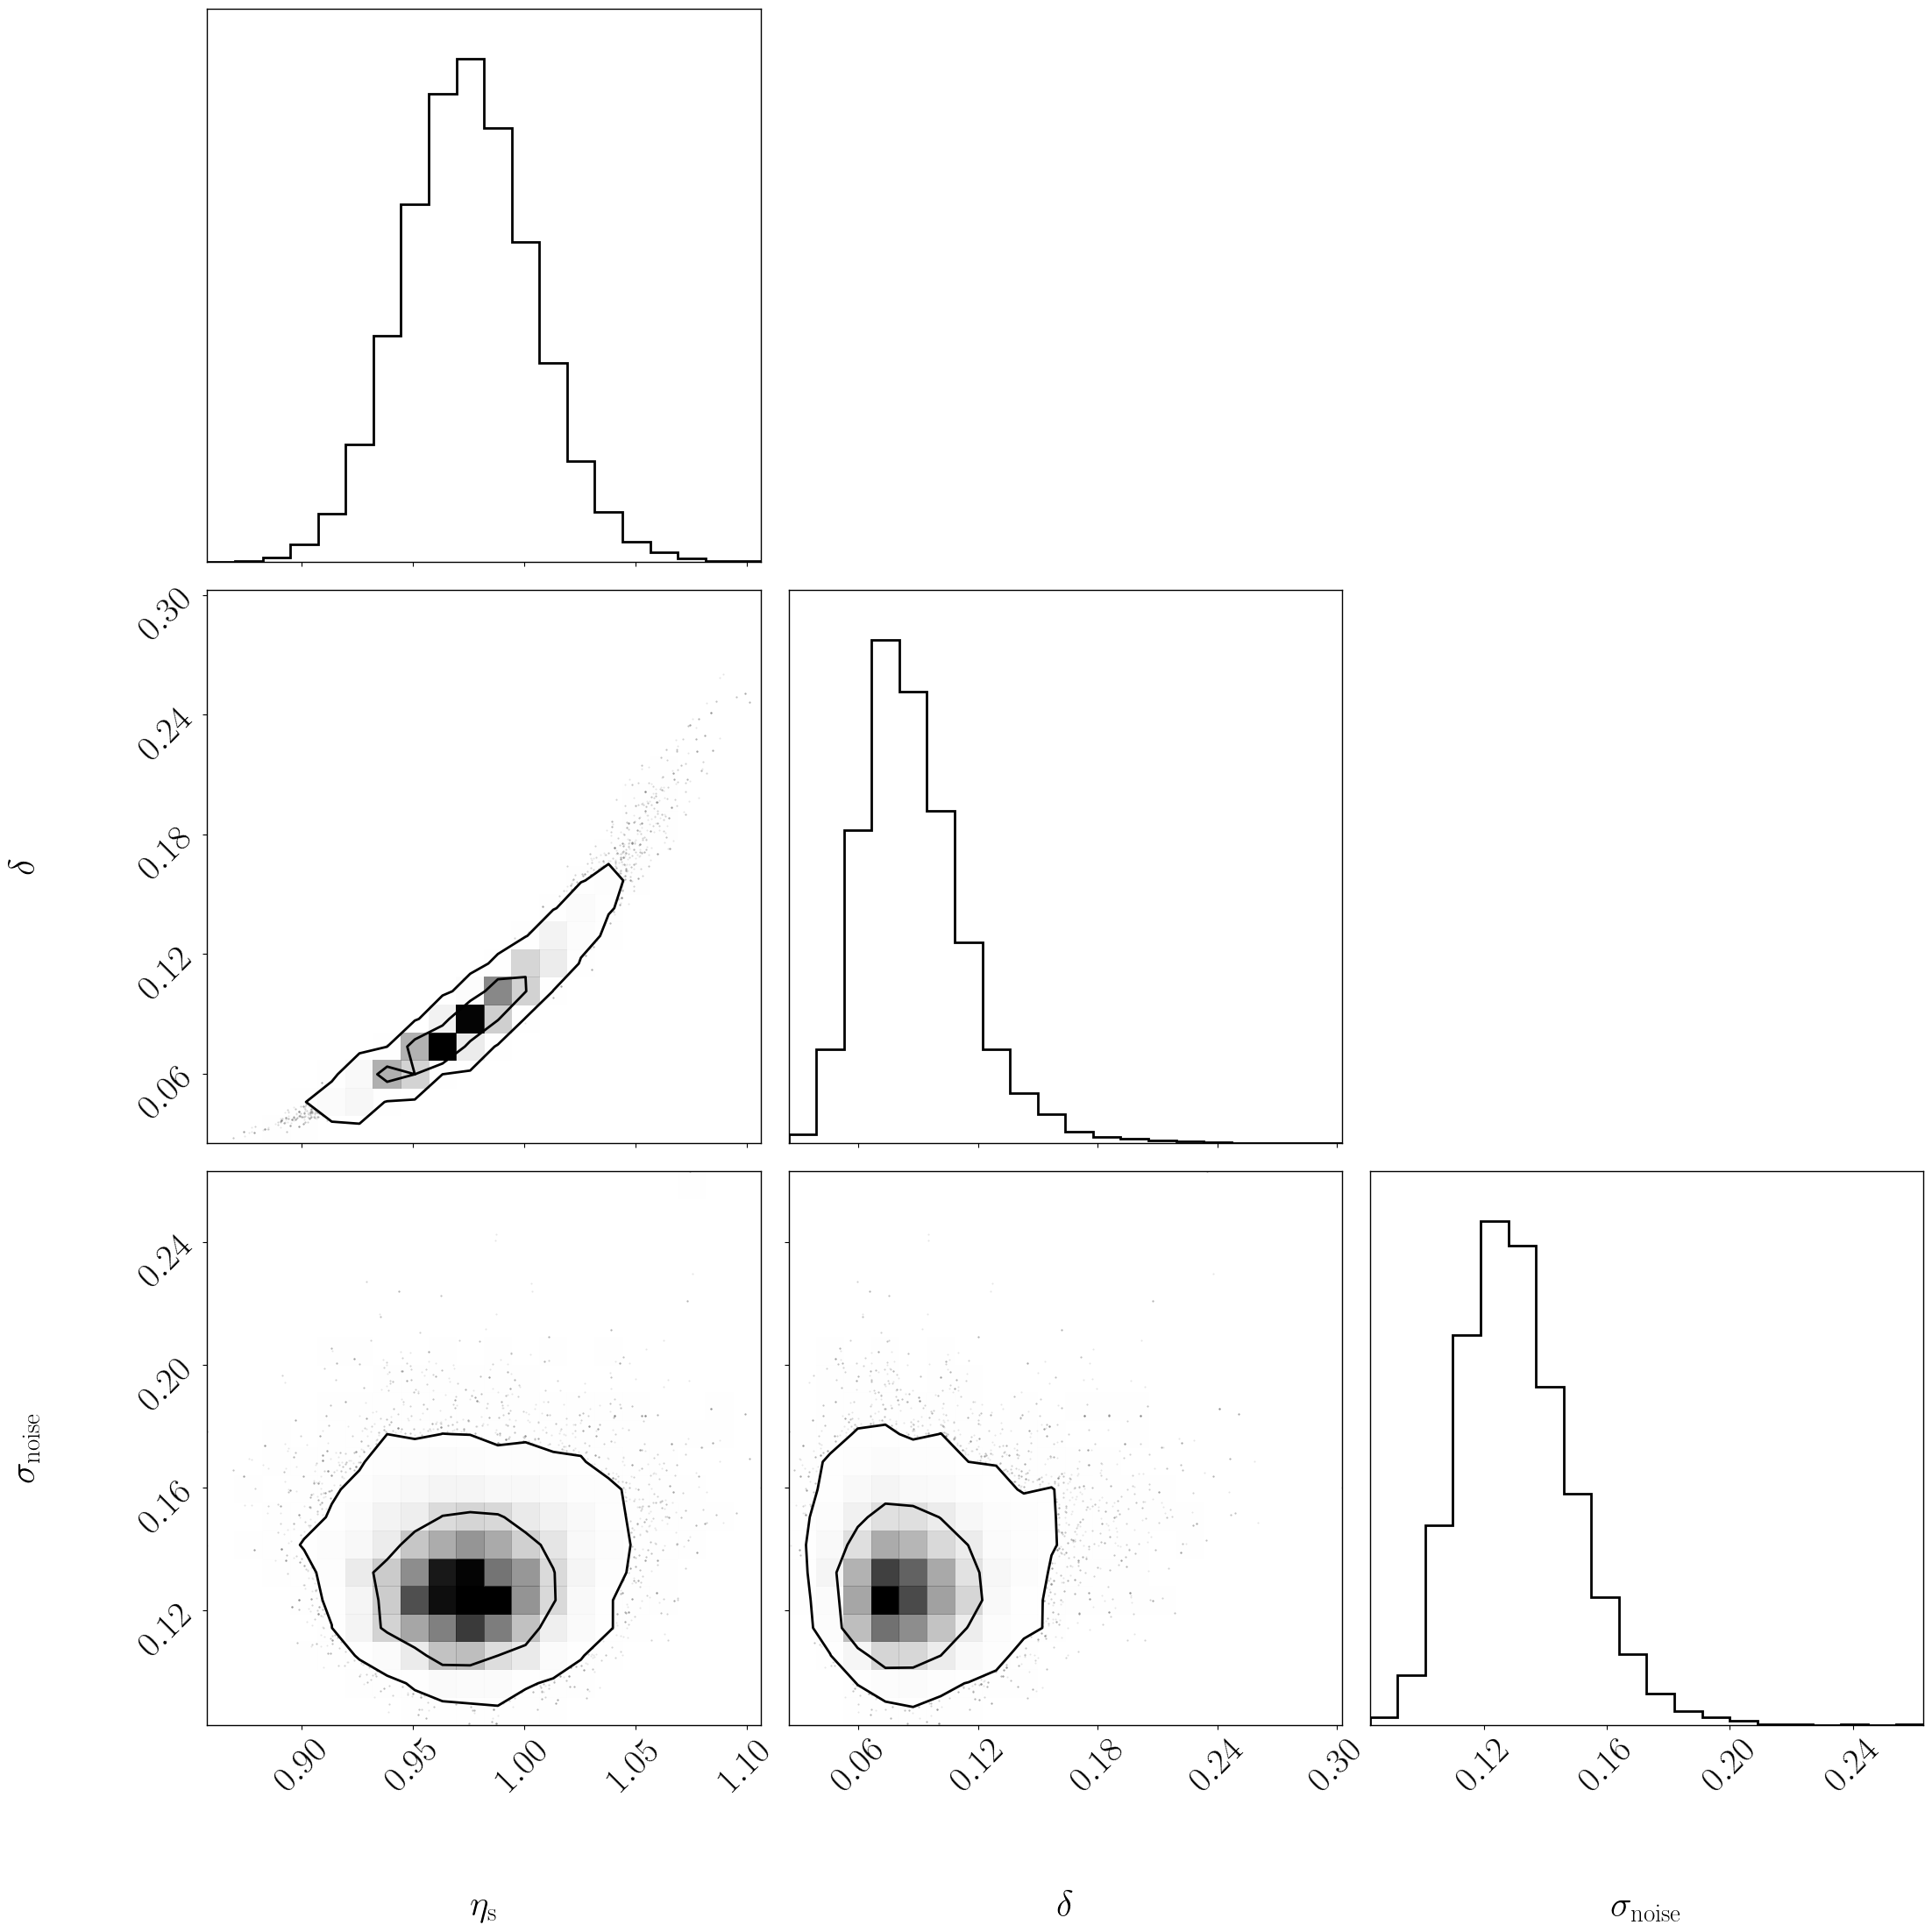

Saved figure: c:\Users\paraj\Documents\particle_inference_test\examples\plots\trace.pdf


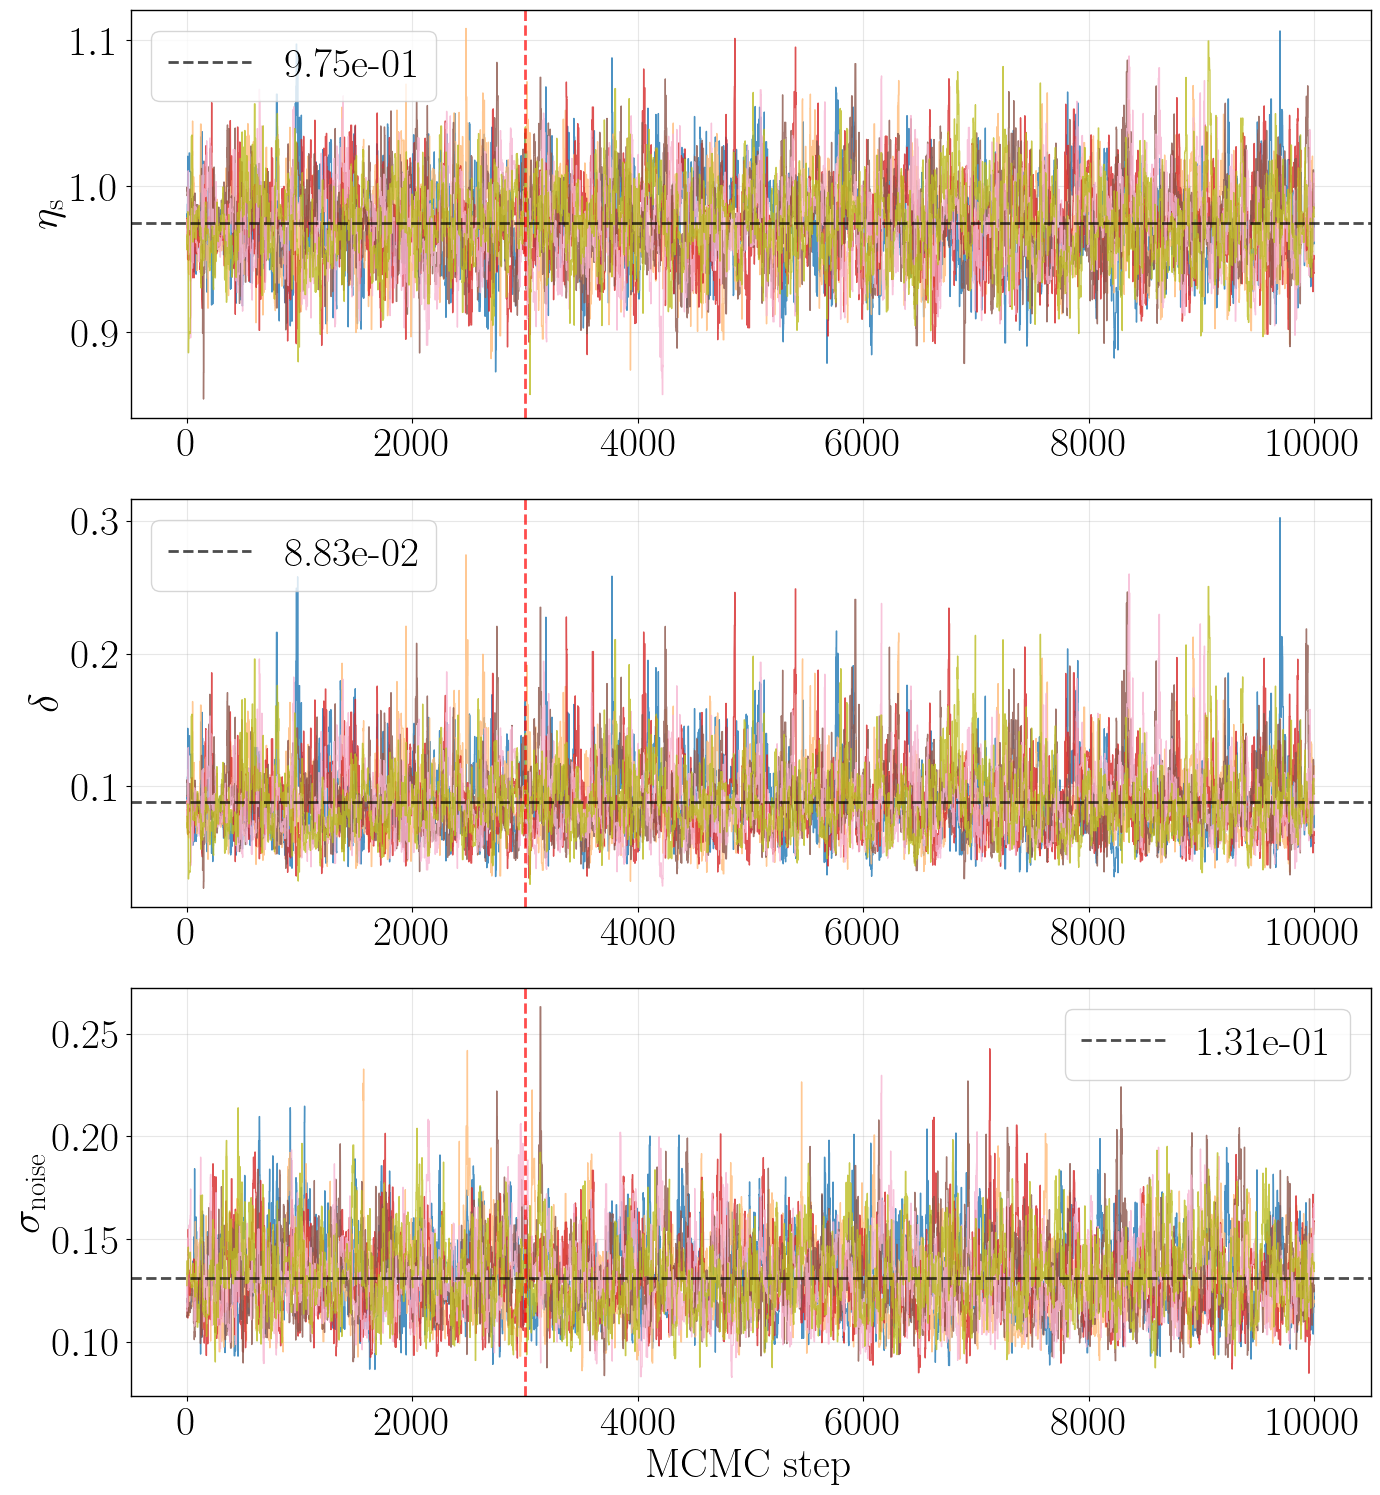

In [1]:
import numpy as np
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from packages.main import  InferenceProcedure

model = InferenceProcedure(
    force=12*np.pi,
    material_model="newtonian", # "newtonian", "viscoelastic"
    boundary_model="bounded", # "unbounded", "bounded"
    theta=45,
    delta0 = 0.1,
    sigma_noise_percent=2.0,
    sigma_bias = None,
    nsteps=10000,
    thin_factor=1)

model.load_data("data/newtonian/angle-45/delta-0.1-45.txt")
model.plot_data(theta_true=[1.0, 0.1])
model.plot_model_error(theta_true = [1.0, 0.1])
model.plot_prior()
model.run_mcmc(init_method= "kmeans")
model.plot_results()